In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.shape

(244, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.describe

<bound method NDFrame.describe of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [7]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

1. 범주형 데이터 구분 > 범주형 데이터 분석

In [12]:
#성별 별로 몇명이 왔는지 문제정의 가능
df['sex'].unique()

['Female', 'Male']
Categories (2, object): ['Male', 'Female']

In [57]:
#남녀가 몇명이 왔는지
male = df['sex']=='Male'
female = df['sex']=='Female'
print(f"남성 : {male.sum()}")
print(f"여성 : {female.sum()}")

남성 : 157
여성 : 87


In [58]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

2. 외식비용 총금액과 총금액의 관계 분석

1) Scatter plot

<Axes: xlabel='total_bill', ylabel='tip'>

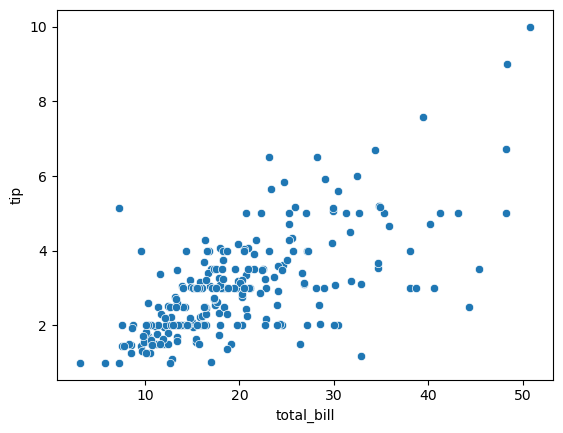

In [59]:
sns.scatterplot(x = df['total_bill'], y = df['tip'])

<Axes: xlabel='total_bill', ylabel='tip'>

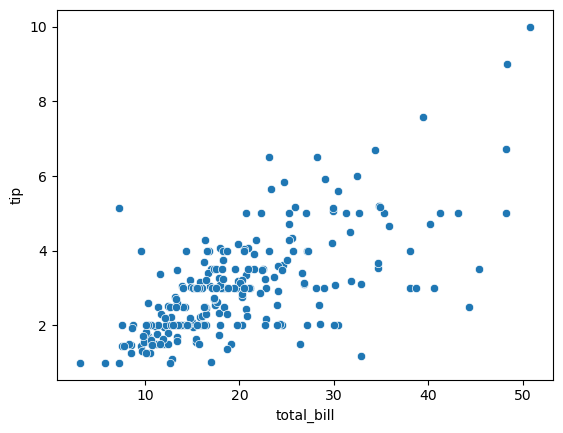

In [60]:
sns.scatterplot(data = df, x = 'total_bill', y = 'tip')

<Figure size 400x300 with 0 Axes>

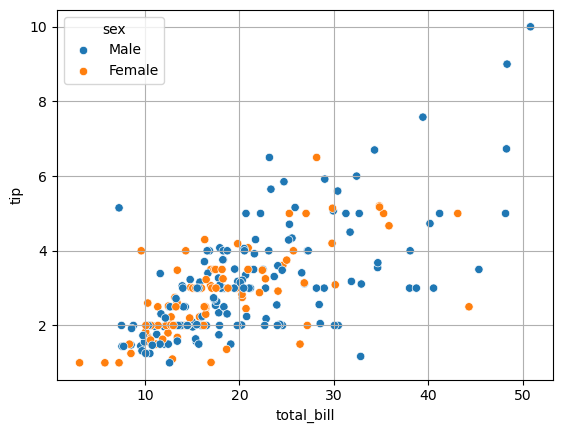

<Figure size 400x300 with 0 Axes>

In [61]:
sns.scatterplot(x = df['total_bill'], y = df['tip'], hue = df['sex'])
plt.grid()
plt.figure(figsize = [4,3])

- 총 지불비용이 커짐에 따라 tip 발생 금액은 커짐 => 비례함
- 남성의 경우, 50불 이상 식사 비용을 지불할 때, 10% 팁이 통상 팁으로 간주할때 팁 비율이 평균 팁 비율보다 상위에서 지불되는 경향이 존재함
- 여성의 경우, 10불 이하 지불시 통상 팁 비율보다 1불 이하의 팁으로 발생되는 경우가 존재함
- 남성의 경우 상대적으로 정상적인 팁 비율보다 상위하는 금액으로 팁이 발생하는 경우가 관찰됨

<Figure size 800x100 with 0 Axes>

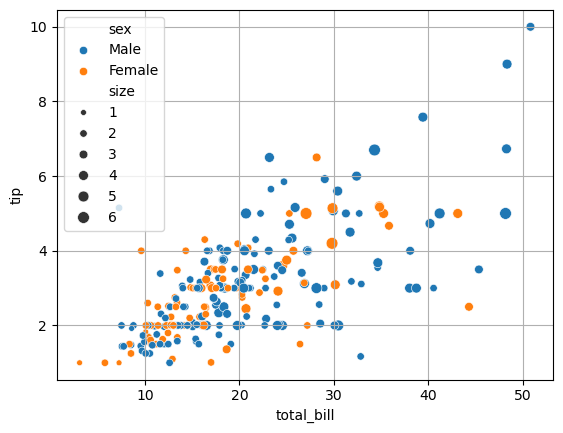

<Figure size 800x100 with 0 Axes>

In [14]:
sns.scatterplot(x = df['total_bill'], y = df['tip'], hue = df['sex'],size = df['size'])
plt.grid()
plt.figure(figsize = (8,1))

- 남성의경우 상대적으로 여러명 방문하여 30불 이상의 식사비용을 지불하는 경향이 있다
- 전체적으로 팁은 2~4달러 구간에서 형성됨

[전체적 데이터 인사이트 분석]
- 식사 금액이 높을수록 팁도 증가하는 경향이 존재함
- 식사 총 금액이 10~20달러인 경우는주로 팁은1~4달러 사이에 집중되어 있음
- 총 금액이 30달러 이상인 경우 팁이 4달러 이상으로 올라가는 경우가 존재함

[남성/여성 고객데이터]
- 파란색 점인 남성 데이터가 전체적으로 더 넓은범위에 분포되어서 존재함
- 통 외식 비용이 30달러 이상이거나 팁이 6달러 이상인 고금액 구간에서는 남성 데이터가 상대적으로 많이 관찰됨
- 여성 데이터는중간 금댁대에서 많이 분포하고, 매우 높은 결제 금액과 팁 구간에서는 남성 데이터가 더 두드러지게 나타남

[특이값 분석]
- 오른쪽 상단 총 외식 비용이 약 50달러 이상이고, 팁이 10달러 정도인 데이터가 존재함
- 매우 높은 결제금액과 높은 팁이 발생한 특이치 데이터로 관찰이 필요함
- 그러나, 결제금액이 40달러 이상인데 팁은 2~3달러 수준인 데이터도 존재하고 있음

[인원사이즈 분석]
- 3인 이상의 단체 식사의 경우 주로 20달러 이상에서 형성되어 있음
- 1인 식사는 15달러 이하에서 관측되는데도 불구하고 3인 이상은 주로 20~30달러 구간에서 데이터가 존재
- 20달러 이상에서 여성의 경우 같은 사이즈임에도 팁의 발생 패턴이 상이함
- 상대적으로 식사 그룹중 큰 4명 이상의 경우, 25달러 이상 구간에서 많이 나타남

인원수가 많아도 팁이 항상 높은 것은 아닌것으로 분석됨

# 알고리즘 = 모델, 함수X

<Axes: xlabel='total_bill', ylabel='tip'>

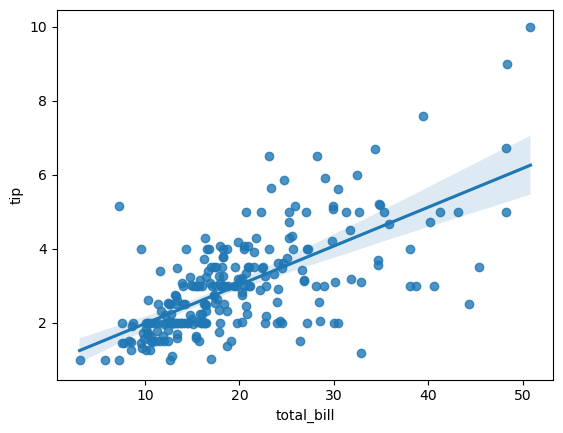

In [63]:
sns.regplot(data = df, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

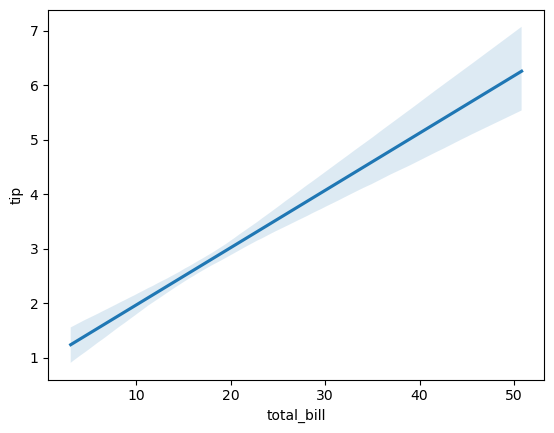

In [64]:
sns.regplot(data = df, x = 'total_bill', y = 'tip', scatter= False)

<Axes: xlabel='total_bill', ylabel='size'>

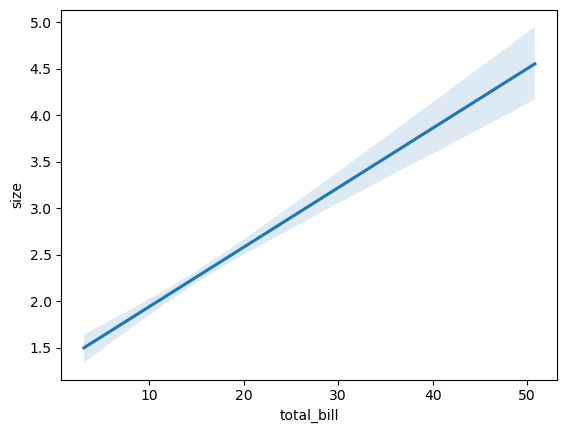

In [70]:
sns.regplot(data = df, x = 'total_bill', y = 'size', scatter= False, ci = 90) # confidence level

<Axes: xlabel='tip', ylabel='total_bill'>

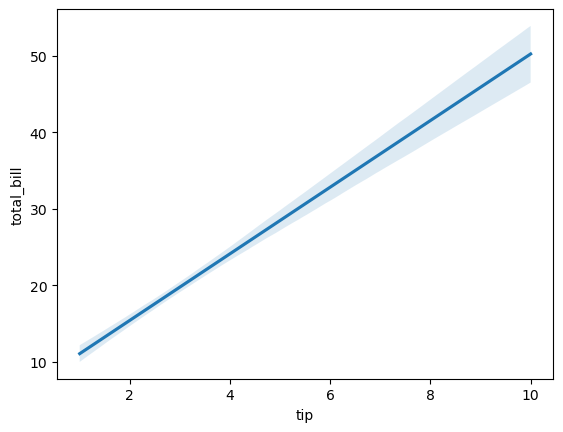

In [69]:
sns.regplot(data = df, x = 'tip', y = 'total_bill', scatter= False, ci = 90) # confidence level

<Axes: xlabel='size', ylabel='tip'>

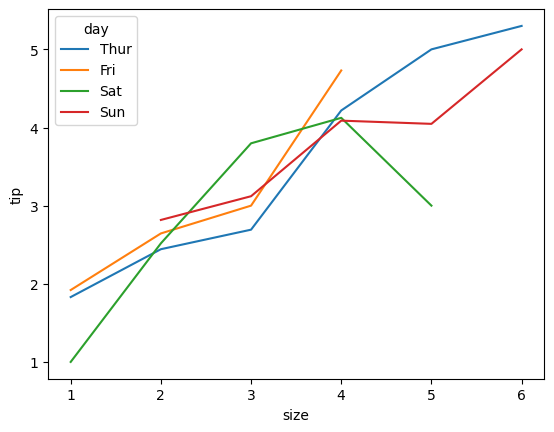

In [75]:
sns.lineplot(x = df['size'], y = df['tip'], hue = df['day'], errorbar = None)

<Axes: xlabel='size', ylabel='tip'>

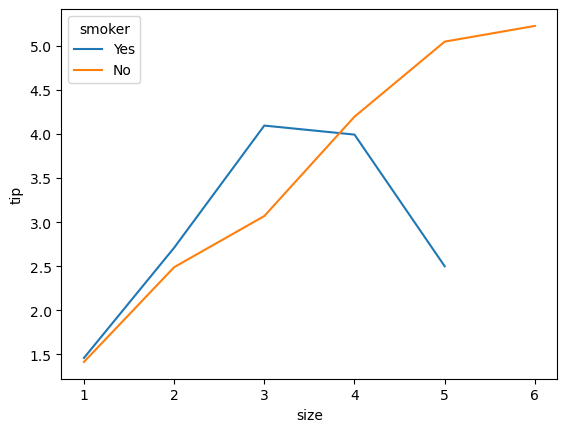

In [76]:
 sns.lineplot(x = df['size'], y = df['tip'], hue = df['smoker'], errorbar = None)

- 흡연자 그룹은 size가 4이상부터 지불한 팁의 값이 떨어진다.
- 흡연자 그룹과 비흡연자 그룹은 인원수 4이상부터 팁 지불금액이 반대의 경향을 보인다.

<Axes: xlabel='total_bill', ylabel='tip'>

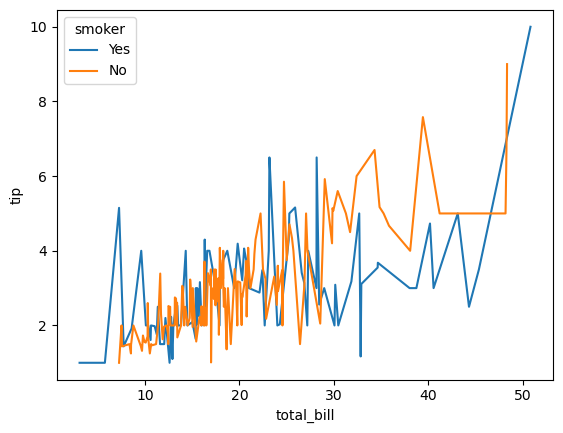

In [79]:
sns.lineplot(x = df['total_bill'], y = df['tip'], hue = df['smoker'], errorbar = None)

- 식사비용 30이하의 구간에서 두 그룹간에 유사하지만 30이상에서는 비흡연자 그룹에서 더 많은 팁을 지불하는 경향이 있다.
- 흡연자 그룹에서 식사비용의 40이상 구간에서 팁 금액이 급격히 증가하고 있다.

In [83]:
import warnings

warnings.filterwarnings('ignore')

<Axes: xlabel='size', ylabel='tip'>

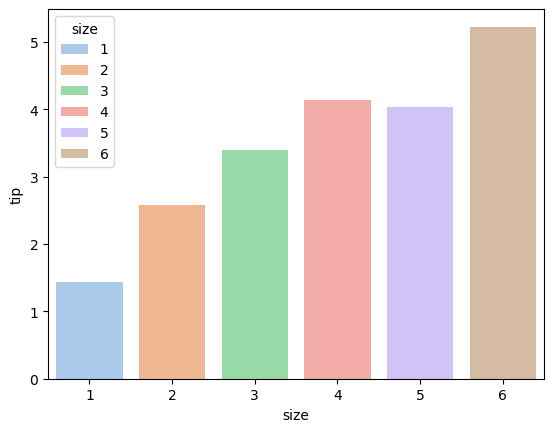

In [85]:
sns.barplot(x=df['size'], y=df['tip'], hue = df['size'], palette = 'pastel', errorbar = None)

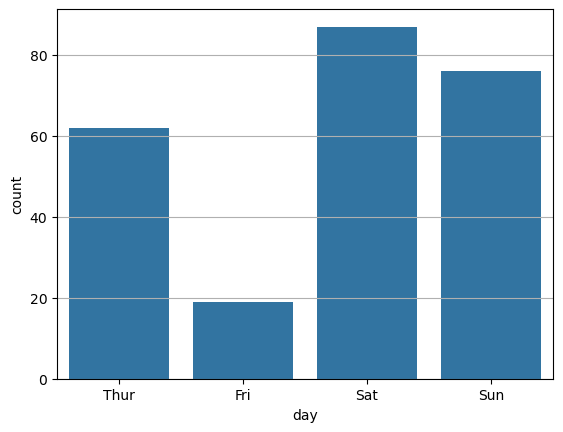

In [88]:
sns.countplot(x=df['day'])
plt.grid(axis ='y') 

In [89]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

<Axes: xlabel='tip', ylabel='day'>

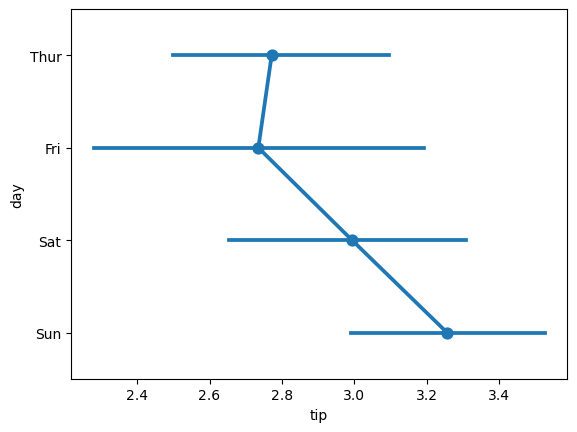

In [90]:
sns.pointplot(x=df['tip'],y=df['day'])

<Axes: xlabel='size', ylabel='tip'>

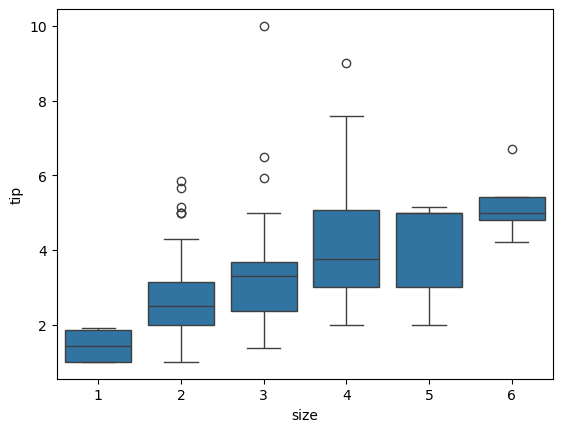

In [92]:
sns.boxplot(x=df['size'],y=df['tip'])

<Axes: xlabel='size', ylabel='tip'>

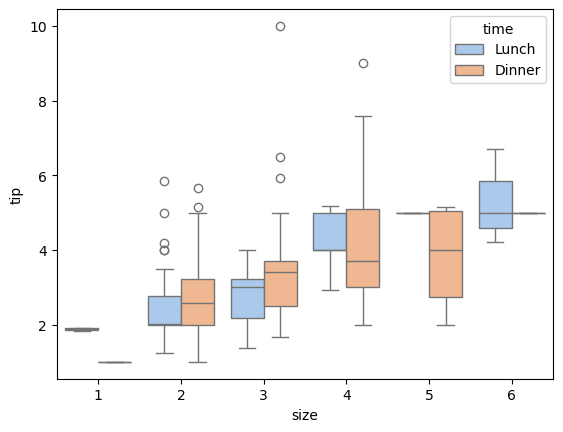

In [94]:
sns.boxplot(x=df['size'],y=df['tip'],hue=df['time'], palette = 'pastel')

<Axes: xlabel='size', ylabel='tip'>

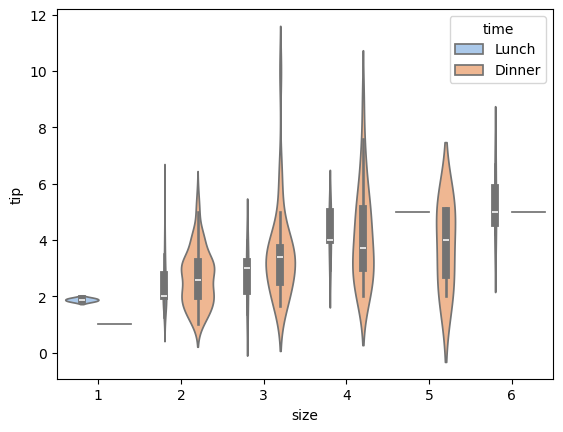

In [95]:
sns.violinplot(x=df['size'],y=df['tip'],hue=df['time'], palette = 'pastel')

<Axes: xlabel='total_bill', ylabel='Count'>

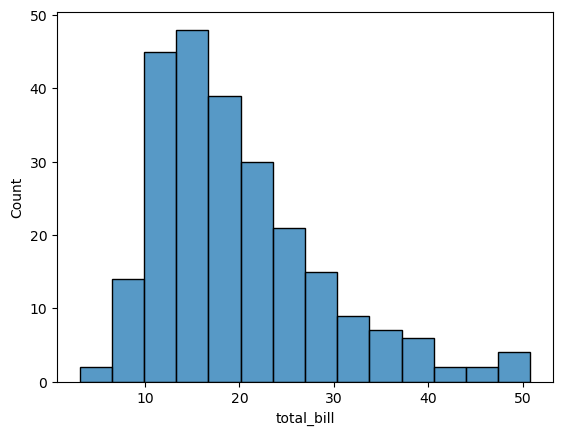

In [96]:
sns.histplot(df['total_bill'])

<Axes: xlabel='total_bill', ylabel='Count'>

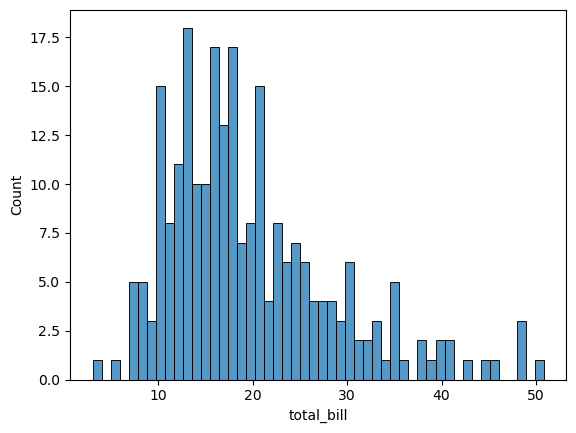

In [100]:
sns.histplot(df['total_bill'], bins = 50)#bins : 막대의 개수

<Axes: xlabel='total_bill', ylabel='Count'>

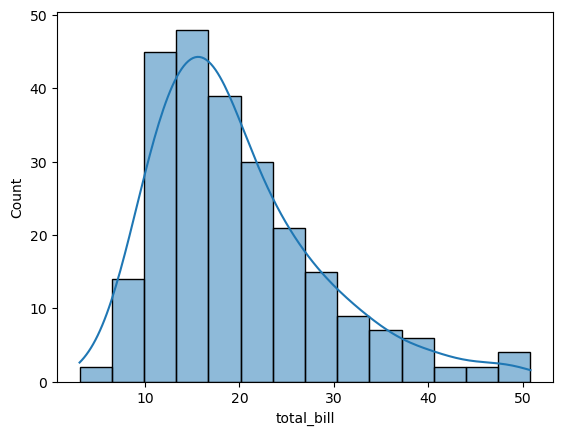

In [102]:
# Kernel Density Estimation(커널밀도함수)
sns.histplot(df['total_bill'], kde = True)

<Axes: xlabel='total_bill', ylabel='Density'>

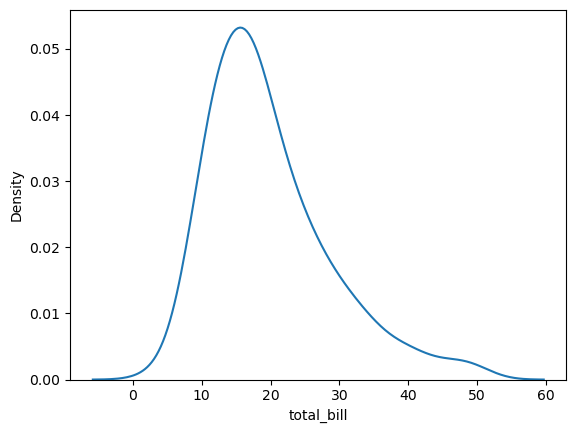

In [104]:
sns.kdeplot(df['total_bill'])

# pivot_table

- pivot table은 데이터를행,열 기준으로 재구성해 합계, 평균 등 집계값을 한눈에 요약하는 기능
- pd.pivot_table()로 구현
- 데이터를 원하는 기준으로 묶어서 요약표를 만드는 함수

In [106]:
#observed =False : 범주형 데이터를 피벗 테이블로 만들때 실제 데이터에 없는 조합까지 표시할지를 결정하는 옵션
#df 데이터프레임에서 day를 행으로, size를 열로 배치하고, 각 요일과 인원수 조합별로 tip의 평균을 계산하는 피벗팅
pivot_df = df.pivot_table('tip','day','size', observed=False)
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0


In [110]:
#집계함수 aggfunc : 피벗테이블에서 같은 그룹으로 묶인 값들을 어떻게 계산하는지를 결정하는 옵션
#mean : 평균, sum : 합계, count : 개수, max : 최댓값 계산, min : 최소값 계산
pivot_df = df.pivot_table('tip','day','size', aggfunc='mean',observed=False)
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,NaN,NaN
Sat,1.00,2.517547,3.797778,4.123846,3.000000,NaN
Sun,NaN,2.816923,3.120667,4.087778,4.046667,5.0


In [112]:
pivot_df.fillna(0, inplace = True)
pivot_df

size,1,2,3,4,5,6
day,,,,,,
Thur,1.83,2.442500,2.692500,4.218000,5.000000,5.3
Fri,1.92,2.644375,3.000000,4.730000,0.000000,0.0
Sat,1.00,2.517547,3.797778,4.123846,3.000000,0.0
Sun,0.00,2.816923,3.120667,4.087778,4.046667,5.0


<Axes: xlabel='size', ylabel='day'>

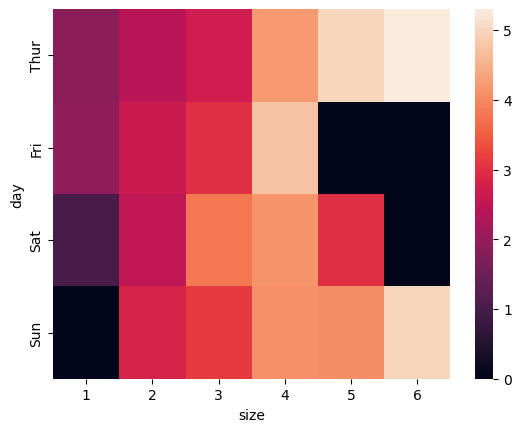

In [113]:
sns.heatmap(pivot_df)

<Axes: xlabel='size', ylabel='day'>

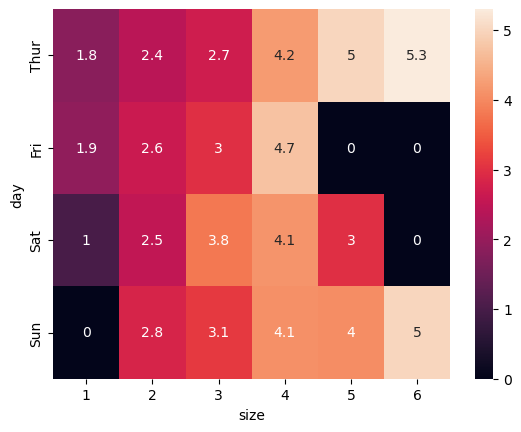

In [114]:
sns.heatmap(pivot_df, annot=True)

In [115]:
#연도별 철도 이용자 수
data = {
    'Month': ['JAN', 'FEB', 'MAR', 'APR', 'MAY'],
    '1958': [340, 318, 362, 348, 363],
    '1959': [360, 342, 406, 396, 420],
    '1960': [417, 391, 419, 461, 472]
}
data

{'Month': ['JAN', 'FEB', 'MAR', 'APR', 'MAY'],
 '1958': [340, 318, 362, 348, 363],
 '1959': [360, 342, 406, 396, 420],
 '1960': [417, 391, 419, 461, 472]}

In [116]:
df = pd.DataFrame(data)

In [117]:
df

,Month,1958,1959,1960
0,JAN,340,360,417
1,FEB,318,342,391
2,MAR,362,406,419
3,APR,348,396,461
4,MAY,363,420,472


In [120]:
pivot_table = df.pivot_table(index = 'Month', aggfunc = 'mean')
pivot_table

,1958,1959,1960
Month,,,
APR,348.0,396.0,461.0
FEB,318.0,342.0,391.0
JAN,340.0,360.0,417.0
MAR,362.0,406.0,419.0
MAY,363.0,420.0,472.0


In [129]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

<Axes: ylabel='Month'>

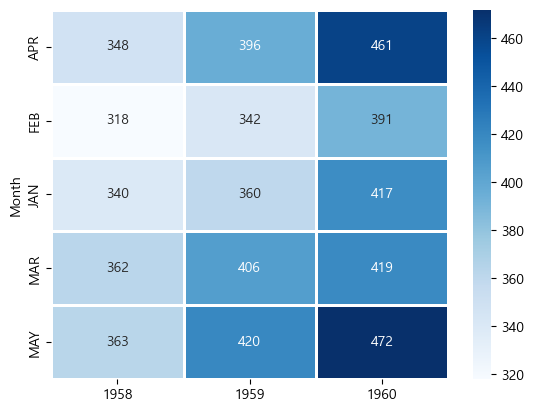

In [135]:
sns.heatmap(
    pivot_table,
    fmt='.0f',
    linewidth = 2,
    linecolor = 'white',
    cmap = 'Blues',
    xticklabels='auto',
    yticklabels='auto',
    annot=True)

- 연도별 철도 이용자 수는 전체적으로 많아짐
-  1959년부터 4월과 5월 이용자 수는 상대적으로 더 늘어남